This dataset contains transactional sales data from an online retail store. Each row represents a single product purchased in a particular transaction. The dataset includes information about the invoice number, product details, quantity purchased, price, customer ID, and the country where the customer is located.

<b>The goal of analyzing this dataset is to understand customer purchasing behavior, sales patterns, product demand, and geographical distribution of customers.</b>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("../data/RawData/Customer_sales.csv", encoding='latin1')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


The dataset is loaded into a Pandas DataFrame. The encoding ISO-8859-1 is used because the dataset contains special characters £,é,ä in product descriptions.

In [3]:
df = pd.DataFrame(data)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

The dataset contains 541,909 records and 8 features. Each record corresponds to a product purchased within a transaction.

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

| Column      | Description                                |
| ----------- | ------------------------------------------ |
| InvoiceNo   | Unique number assigned to each transaction |
| StockCode   | Unique code for each product               |
| Description | Name of the product                        |
| Quantity    | Number of items purchased                  |
| InvoiceDate | Date and time when transaction occurred    |
| UnitPrice   | Price per unit of the product              |
| CustomerID  | Unique ID of the customer                  |
| Country     | Country where the customer lives           |


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.6 MB


The info() function provides a summary of the dataset including column names, number of non-null values, and data types. It helps identify missing values and understand whether columns are numerical or categorical.

Important observations:

Quantity → Numeric

UnitPrice → Numeric

CustomerID → Numeric but actually categorical

InvoiceDate → DateTime (should be converted)

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

The dataset contains missing values in the Description and CustomerID columns. Missing customer IDs indicate transactions where the customer was not registered or identified.

In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


The describe() function provides summary statistics of numerical columns such as mean, minimum, maximum, and standard deviation.

Important insights:

Average customer ID ≈ 15287

Quantity varies widely

Some transactions may contain very large quantities

# Key Observations About Dataset
Key observations from the dataset:

The dataset contains more than 500k transaction records.

The majority of transactions come from the United Kingdom.

Some values are missing in the CustomerID and Description columns.

Each invoice may contain multiple products.

Quantity values represent the number of items purchased in a transaction.

# Feature Engineering

## Convert Date Columnm

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

The InvoiceDate column is converted into datetime format so that time-based features such as year, month, and hour can be extracted later.

## Remove Missing Customer IDs

In [10]:
df = df.dropna(subset=['CustomerID'])

Transactions without a CustomerID are removed because customer segmentation requires identifying unique customers. Records without customer identifiers cannot be used for segmentation.

## Remove Negative Quantities

In [11]:
df = df[df['Quantity'] > 0]

Negative quantities correspond to returned items. Since customer segmentation focuses on purchase behavior, returned transactions are removed to avoid misleading purchase patterns.

## Remove Invalid Prices

In [12]:
df = df[df['UnitPrice'] > 0]

Rows where UnitPrice equals zero are removed because they represent invalid or free transactions that may distort revenue calculations.

## Create Total Transaction Value

In [13]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df.loc[df['TotalPrice'] == df["Quantity"] * df["UnitPrice"]].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


A new feature called TotalPrice is created by multiplying the quantity purchased with the unit price. This represents the total value of each transaction and is essential for calculating customer spending.

## Extract Time Features

### Month

In [14]:
df["Month"] =  df["InvoiceDate"].dt.month
df.loc[df['Month'] == df["InvoiceDate"].dt.month].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [15]:
df[['Month']].value_counts()

Month
11       64531
10       49554
12       43461
9        40028
5        28320
6        27185
3        27175
8        27007
7        26825
4        22642
1        21229
2        19927
Name: count, dtype: int64

The month of each transaction is extracted to analyze seasonal purchasing behavior.

### Day Of Week

In [16]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df.loc[df['DayOfWeek'] == df["InvoiceDate"].dt.day_name()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday


In [17]:
df[['DayOfWeek']].value_counts()

DayOfWeek
Thursday     80035
Wednesday    68885
Tuesday      66473
Monday       64893
Sunday       62773
Friday       54825
Name: count, dtype: int64

This feature identifies the day of the week when transactions occur, which can reveal patterns in customer purchasing habits.

### Hours

In [18]:
df["Hour"] = df["InvoiceDate"].dt.hour
df.loc[df['Hour'] == df["InvoiceDate"].dt.hour].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8


The hour feature helps analyze at what time customers are most active.

## Most Quantity of a Product

In [19]:
Most_Quantity = df['Description'].value_counts()
mq = pd.DataFrame(Most_Quantity)
mq.iloc[:20]

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2028
REGENCY CAKESTAND 3 TIER,1723
JUMBO BAG RED RETROSPOT,1618
ASSORTED COLOUR BIRD ORNAMENT,1408
PARTY BUNTING,1396
LUNCH BAG RED RETROSPOT,1316
SET OF 3 CAKE TINS PANTRY DESIGN,1159
LUNCH BAG BLACK SKULL.,1105
POSTAGE,1099


This Method has showed the value counts of the top 20 highest purchased products in sales

# Create Customer-Level Dataset

In [20]:
customer_df = df.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "TotalPrice": "sum",
    "InvoiceDate": ["min", "max"]
})

customer_df.head()

InvoiceNo Quantity TotalPrice         InvoiceDate  \
             nunique      sum        sum                 min   
CustomerID                                                     
12346.0            1    74215   77183.60 2011-01-18 10:01:00   
12347.0            7     2458    4310.00 2010-12-07 14:57:00   
12348.0            4     2341    1797.24 2010-12-16 19:09:00   
12349.0            1      631    1757.55 2011-11-21 09:51:00   
12350.0            1      197     334.40 2011-02-02 16:01:00   

                                
                           max  
CustomerID                      
12346.0    2011-01-18 10:01:00  
12347.0    2011-12-07 15:52:00  
12348.0    2011-09-25 13:13:00  
12349.0    2011-11-21 09:51:00  
12350.0    2011-02-02 16:01:00

The dataset is aggregated at the customer level. For each customer, we calculate the number of unique transactions, total quantity purchased, total spending, and the first and last purchase dates.

## Create Customer Lifetime

In [22]:
customer_df = customer_df.reset_index()

customer_df.columns = [
    "CustomerID",
    "TotalTransactions",
    "TotalQuantity",
    "TotalSpending",
    "FirstPurchase",
    "LastPurchase"
]

In [23]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,7,2458,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348.0,4,2341,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00


Column names are simplified for easier interpretation and analysis.

## Create Customer Lifetime

In [24]:
customer_df["CustomerLifetime"] = (
    customer_df["LastPurchase"] - customer_df["FirstPurchase"]
).dt.days

Customer lifetime represents the number of days between the first and last purchase. This metric helps understand how long a customer remains active.

## Create Average Order Value

In [25]:
customer_df["AvgOrderValue"] = (
    customer_df["TotalSpending"] / customer_df["TotalTransactions"]
)

Average order value measures how much a customer spends on average per transaction.

## Create Purchase Frequency

In [26]:
customer_df["PurchaseFrequency"] = (
    customer_df["TotalTransactions"] / (customer_df["CustomerLifetime"] + 1)
)

Purchase frequency represents how often a customer makes purchases during their active period.

## Your customer-level dataset now contains:

| Feature           | Meaning                    |
| ----------------- | -------------------------- |
| CustomerID        | Unique customer            |
| TotalTransactions | Number of purchases        |
| TotalQuantity     | Total items purchased      |
| TotalSpending     | Total money spent          |
| FirstPurchase     | First purchase date        |
| LastPurchase      | Most recent purchase       |
| CustomerLifetime  | Active days                |
| AvgOrderValue     | Average spending per order |
| PurchaseFrequency | Purchase rate              |


## This dataset is now ready for segmentation analysis.

In [27]:
df.shape

(397884, 12)

In [28]:
customer_df.shape

(4338, 9)

<b>Now the difference is clear as Now instead of analyzing 541k transactions, we analyze ~4300 customers, which is much better for segmentation.</b>

In [29]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase,CustomerLifetime,AvgOrderValue,PurchaseFrequency
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0,77183.600000,1.000000
1,12347.0,7,2458,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,365,615.714286,0.019126
2,12348.0,4,2341,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,282,449.310000,0.014134
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1757.550000,1.000000
4,12350.0,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000,1.000000


<h1>Exploratory Data Analysis (EDA)</h1>

The dataset used for exploratory analysis is a customer-level aggregated dataset derived from transaction data. Each row represents a unique customer and contains features describing purchasing behavior such as total spending, number of transactions, average order value, and purchase frequency.

## Set a Professional Visualization Theme

First apply a global theme so all plots look consistent.

In [30]:
import plotly.express as px
import plotly.graph_objects as go

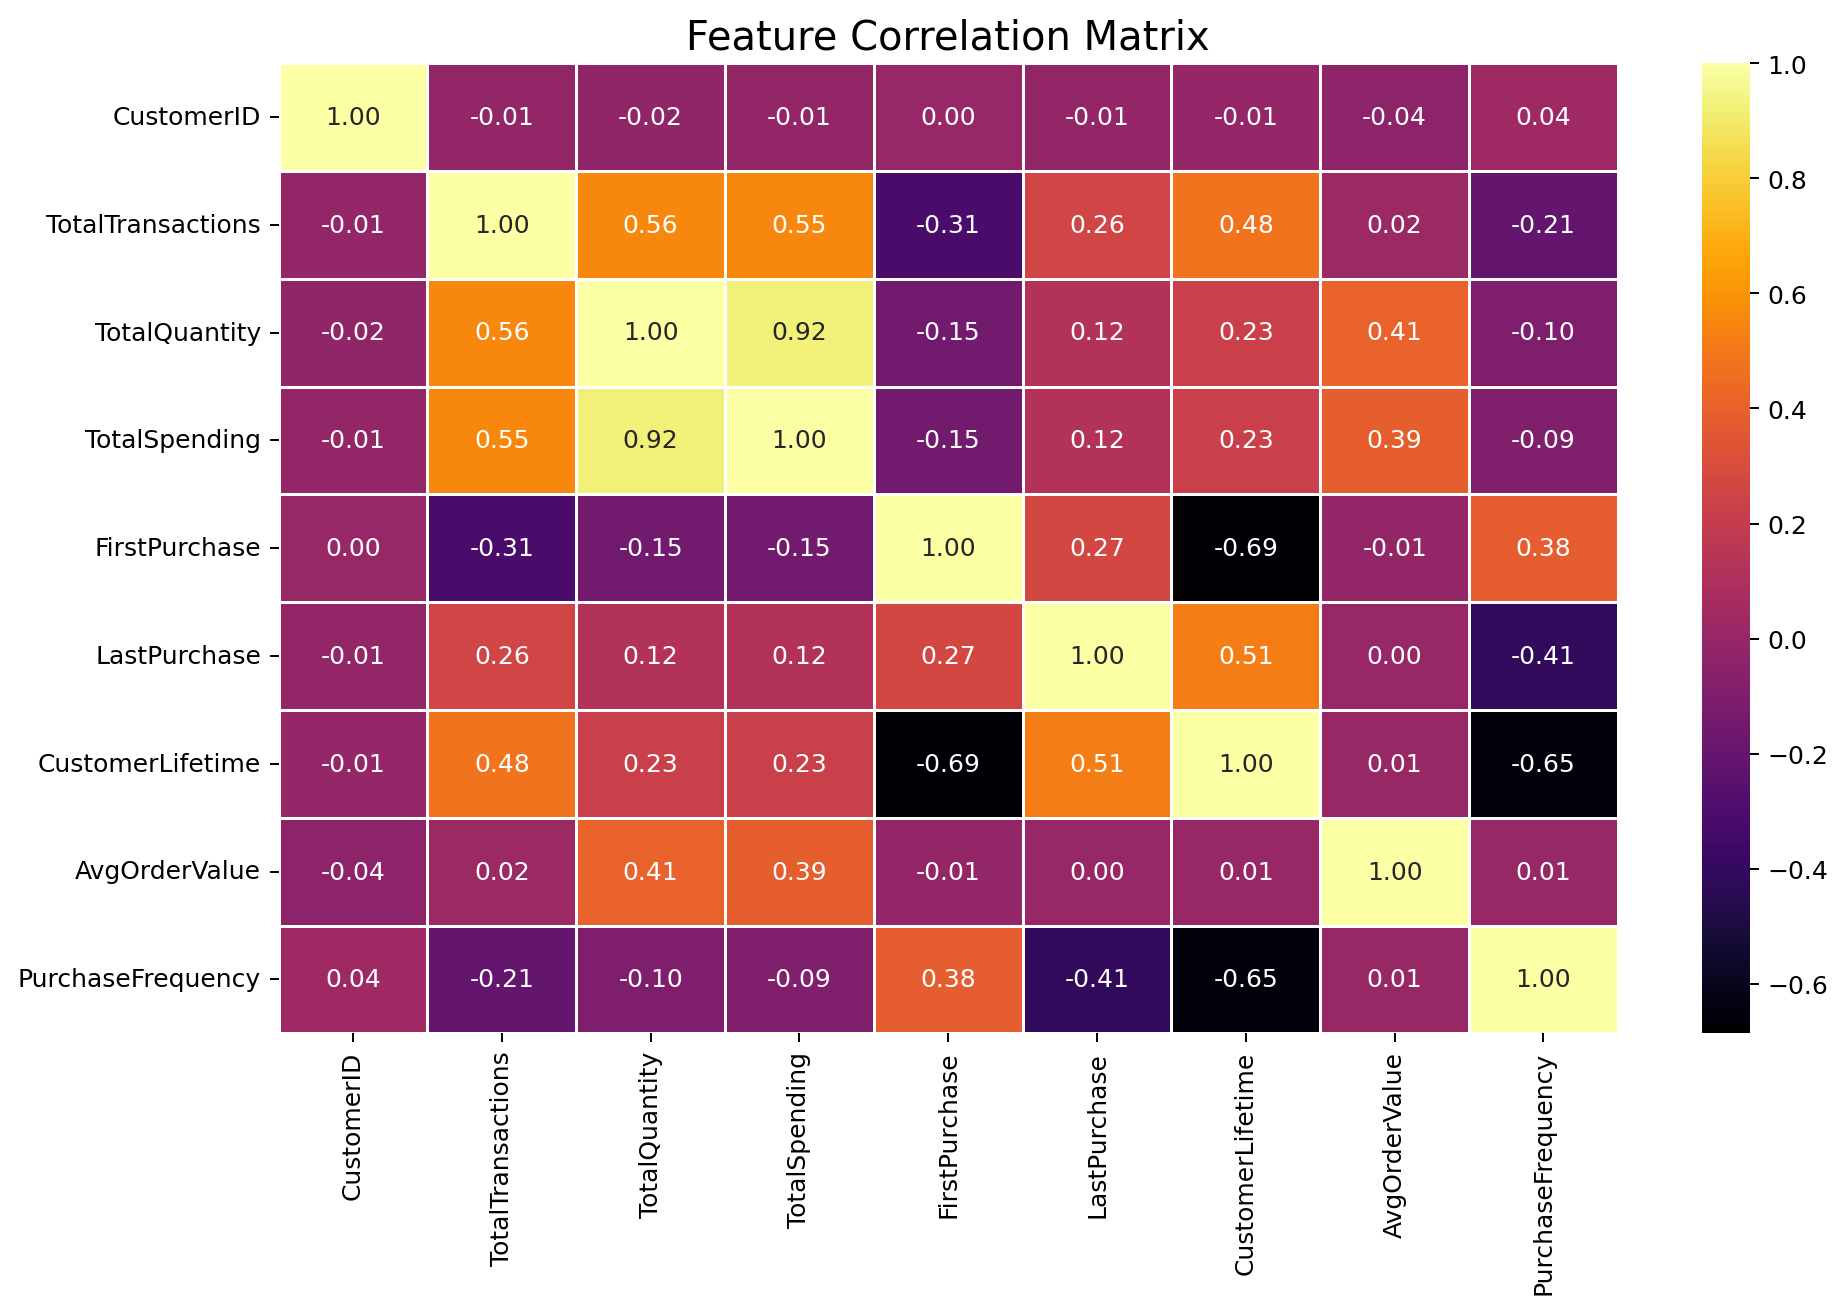

In [31]:
corr = customer_df.corr()

plt.figure(figsize=(12,7), dpi=180)

sns.heatmap(
    corr,
    annot=True,
    cmap="inferno",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# Customer Spending vs Transactions

In [32]:
fig = px.scatter(
    customer_df,
    x="TotalTransactions",
    y="TotalSpending",
    size="TotalQuantity",
    color="AvgOrderValue",
    color_continuous_scale="ylgnbu",
    title="Customer Spending vs Transactions",
    size_max=30
)

fig.update_traces(
    marker=dict(line=dict(width=1, color="black")),
    opacity=0.8,
    marker_line_width=0.5, marker_line_color='white'
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Total Transactions",
    yaxis_title="Total Spending",
    coloraxis_colorbar=dict(title="Avg Order Value"),
    title_x=0.5
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

# Monthly Sales Trend

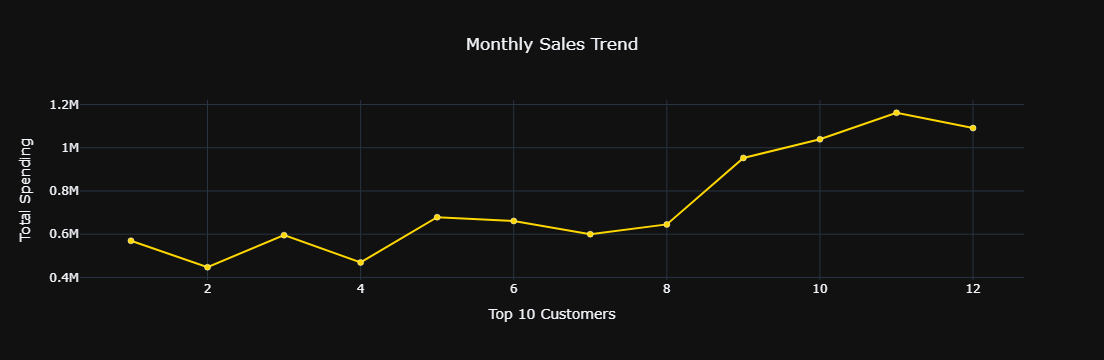

In [ ]:
monthly_sales = df.groupby(
    df['InvoiceDate'].dt.month
)["TotalPrice"].sum().reset_index()

fig = px.line(
    monthly_sales,
    x="InvoiceDate",
    y="TotalPrice",
    markers=True,
    color_discrete_sequence=["gold"],
    title="Monthly Sales Trend"
)

fig.update_traces(
    marker_line_width=0.5, marker_line_color='white'
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Top 10 Customers",
    yaxis_title="Total Spending",
    title_x = 0.5
)

fig.show()

# Box Plot for Outliers

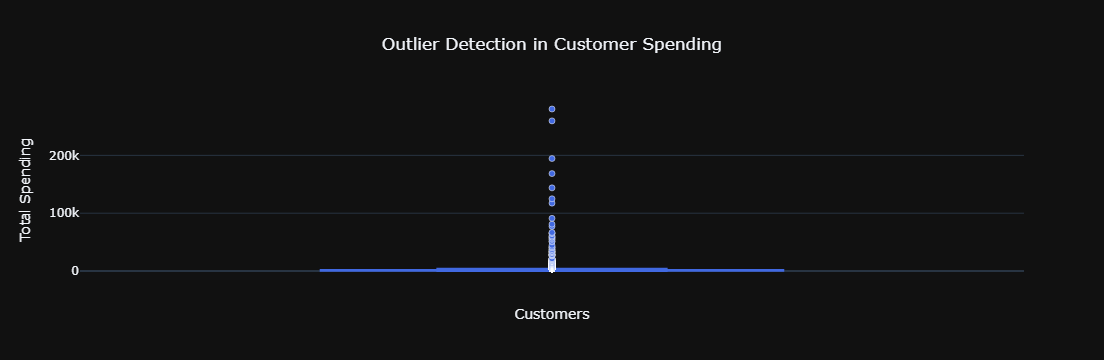

In [ ]:
fig = px.box(
    customer_df,
    y="TotalSpending",
    color_discrete_sequence=["royalblue"],
    title="Outlier Detection in Customer Spending"
)

fig.update_traces(
    marker_line_width=0.5, marker_line_color='white'
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Customers",
    yaxis_title="Total Spending",
    title_x = 0.5
)

fig.show()

# Segmentation-Friendly Bubble Plot

This plot is extremely useful before clustering.
This plot visually shows:

high-value customers

frequent buyers

low-value customers

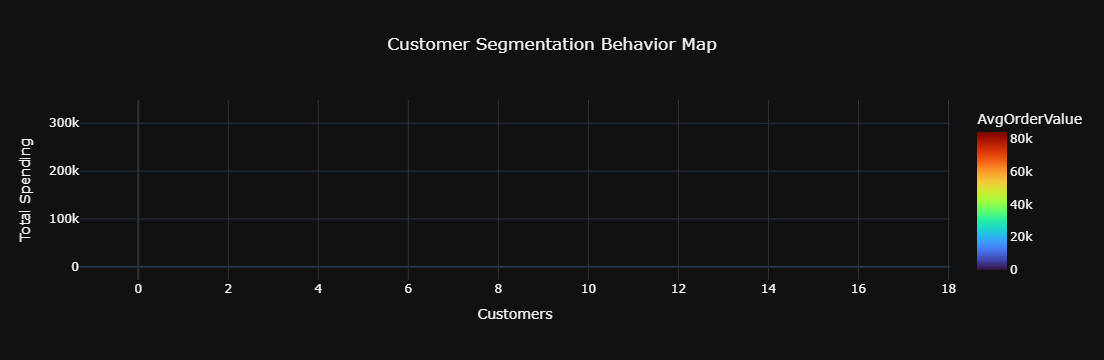

In [ ]:
fig = px.scatter(
    customer_df,
    x="PurchaseFrequency",
    y="TotalSpending",
    size="TotalQuantity",
    color="AvgOrderValue",
    hover_data=["TotalTransactions"],
    color_continuous_scale="Turbo",
    size_max=30,
    title="Customer Segmentation Behavior Map"
)

fig.update_traces(
    marker_line_width=0.5, marker_line_color='white'
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Customers",
    yaxis_title="Total Spending",
    title_x = 0.5
)

fig.show()

This chart highlights frequent buyers vs high spenders, which helps segmentation.

# Spending Distribution

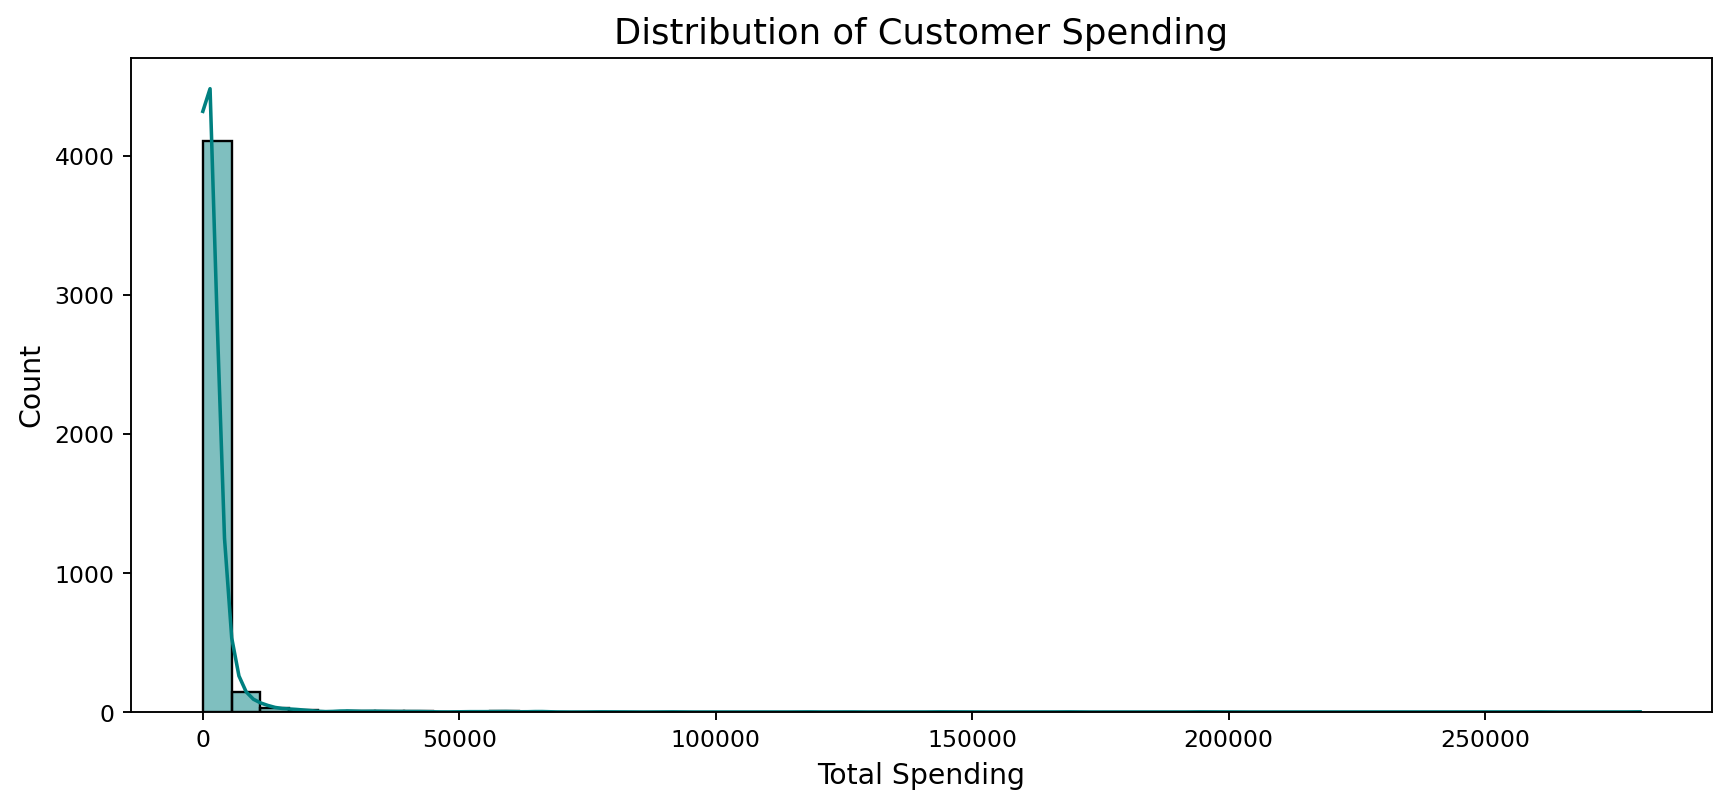

In [ ]:
plt.figure(figsize=(12,5), dpi=170)
sns.histplot(customer_df['TotalSpending'], bins=50, kde=True, color='teal', ec='k')
plt.title("Distribution of Customer Spending", fontsize=15)
plt.xlabel("Total Spending", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

This plot shows how much customers spend overall. Most customers spend relatively small amounts, while a small number of customers contribute significantly higher revenue.

# Average Order Value Distribution

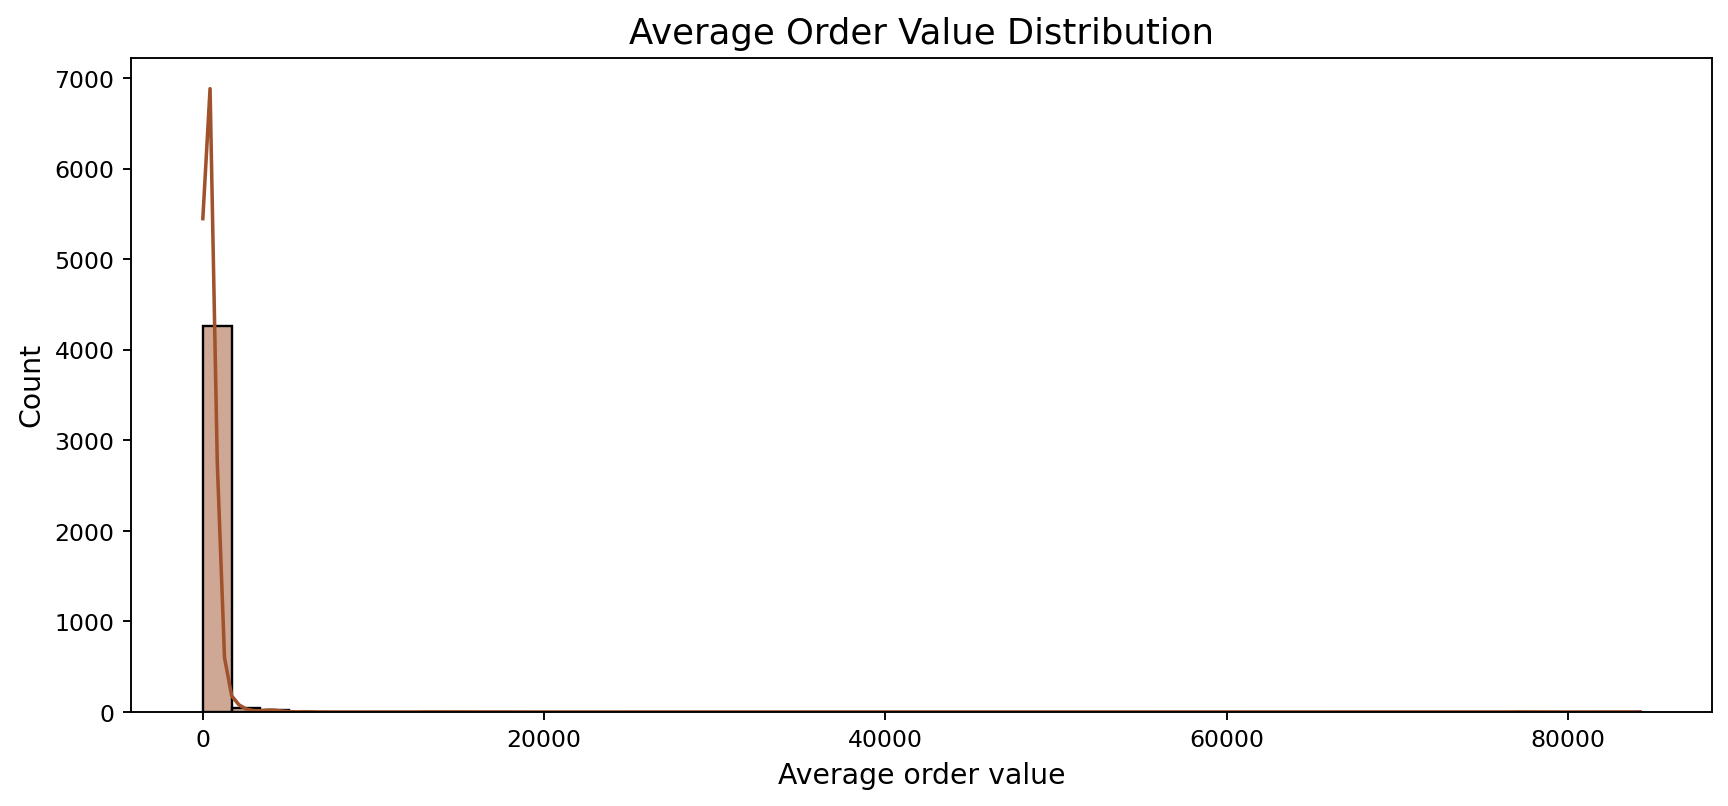

In [ ]:
plt.figure(figsize=(12,5), dpi=170)
sns.histplot(customer_df['AvgOrderValue'], bins=50, kde=True, color='sienna', ec='k')
plt.title("Average Order Value Distribution", fontsize=15)
plt.xlabel("Average order value", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

This visualization helps identify customers who consistently make high-value purchases.

# Purchase Frequency Distribution

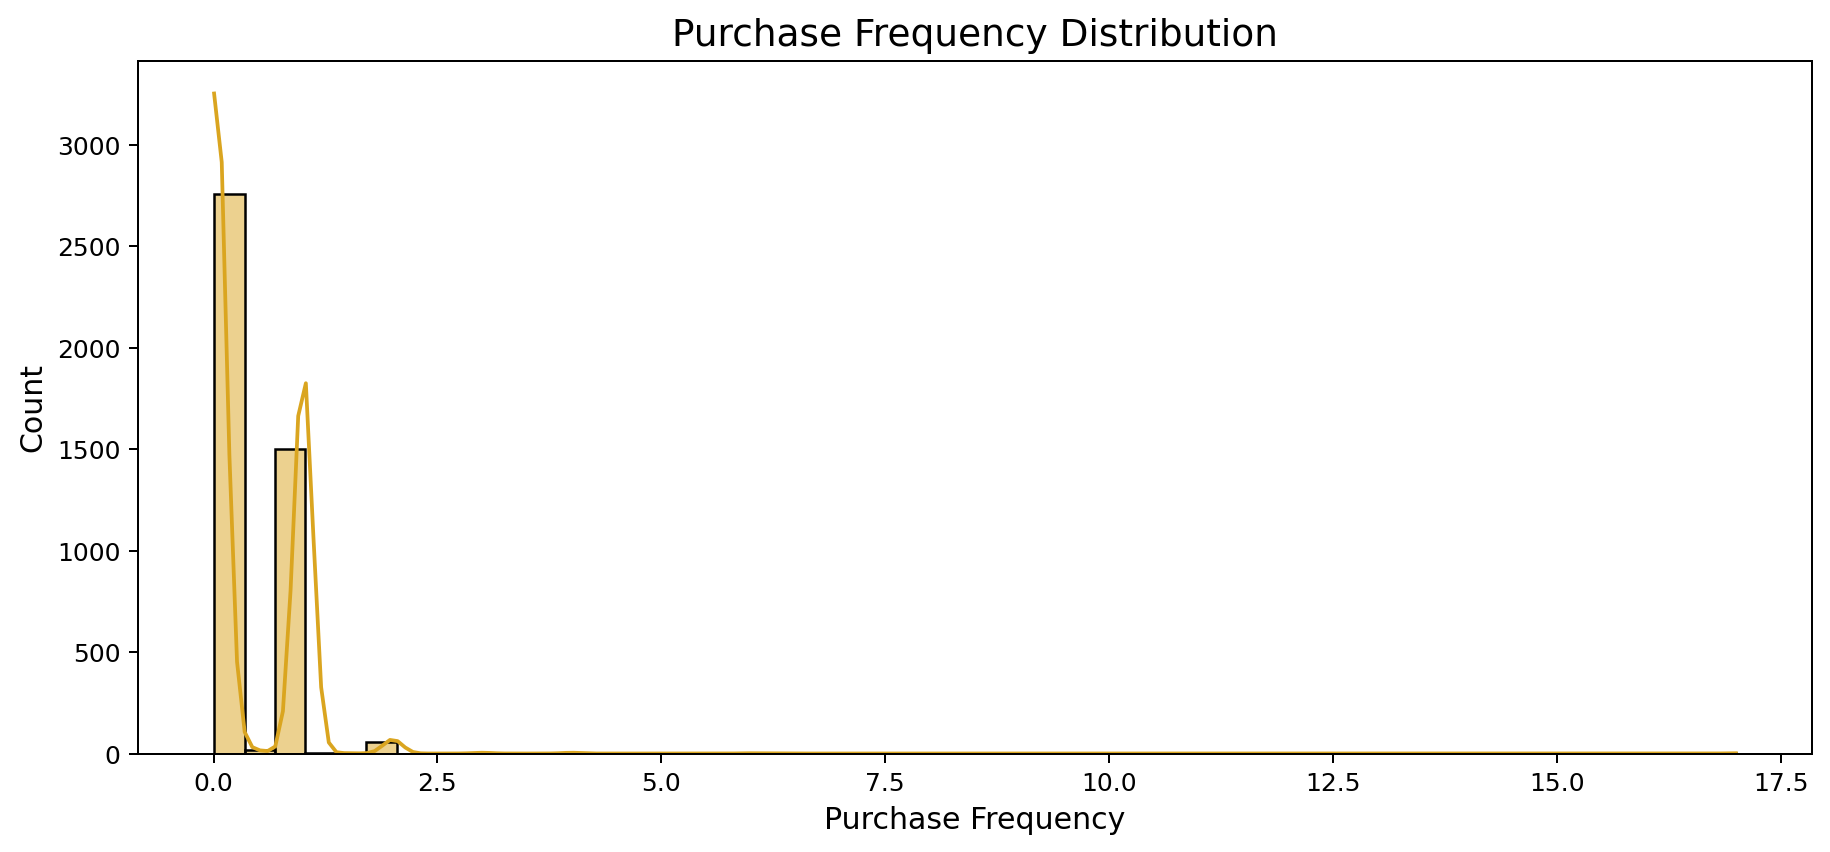

In [ ]:
plt.figure(figsize=(12,5), dpi=180)
sns.histplot(customer_df['PurchaseFrequency'], bins=50, kde=True, color='goldenrod', ec='k')
plt.title("Purchase Frequency Distribution", fontsize=15)
plt.xlabel("Purchase Frequency", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

Customers with high purchase frequency are more engaged and valuable for marketing strategies.

# Customer Lifetime Distribution

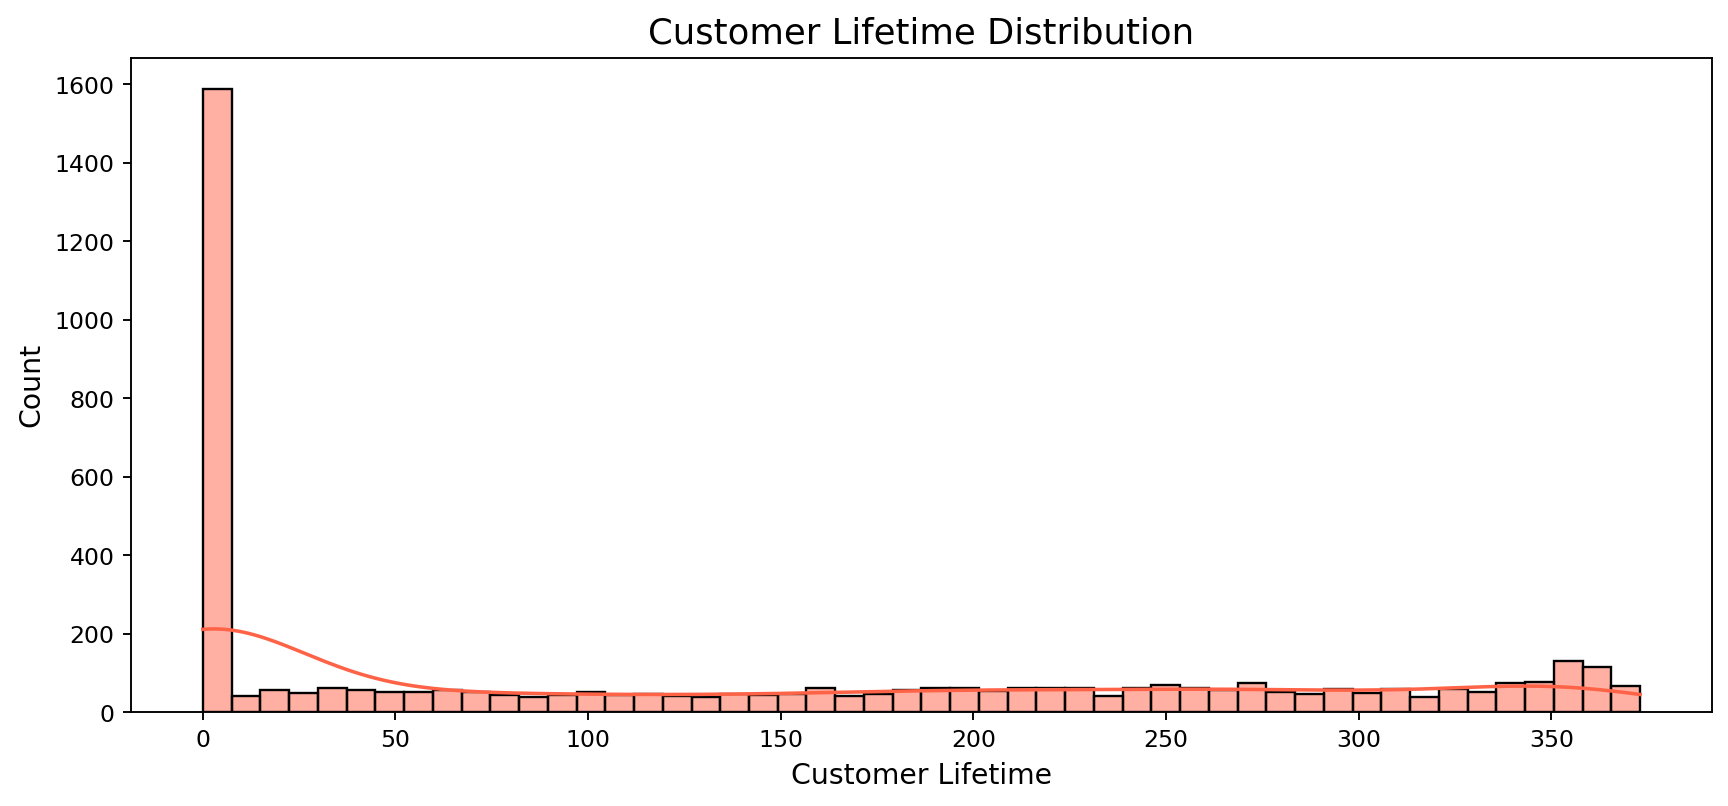

In [ ]:
plt.figure(figsize=(12,5), dpi=170)
sns.histplot(customer_df['CustomerLifetime'], bins=50, kde=True, color='tomato', ec='k')
plt.title("Customer Lifetime Distribution", fontsize=15)
plt.xlabel("Customer Lifetime", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

This shows how long customers remain active in the system. Customers with longer lifetimes indicate stronger retention.

# Total Spending vs Total Transactions

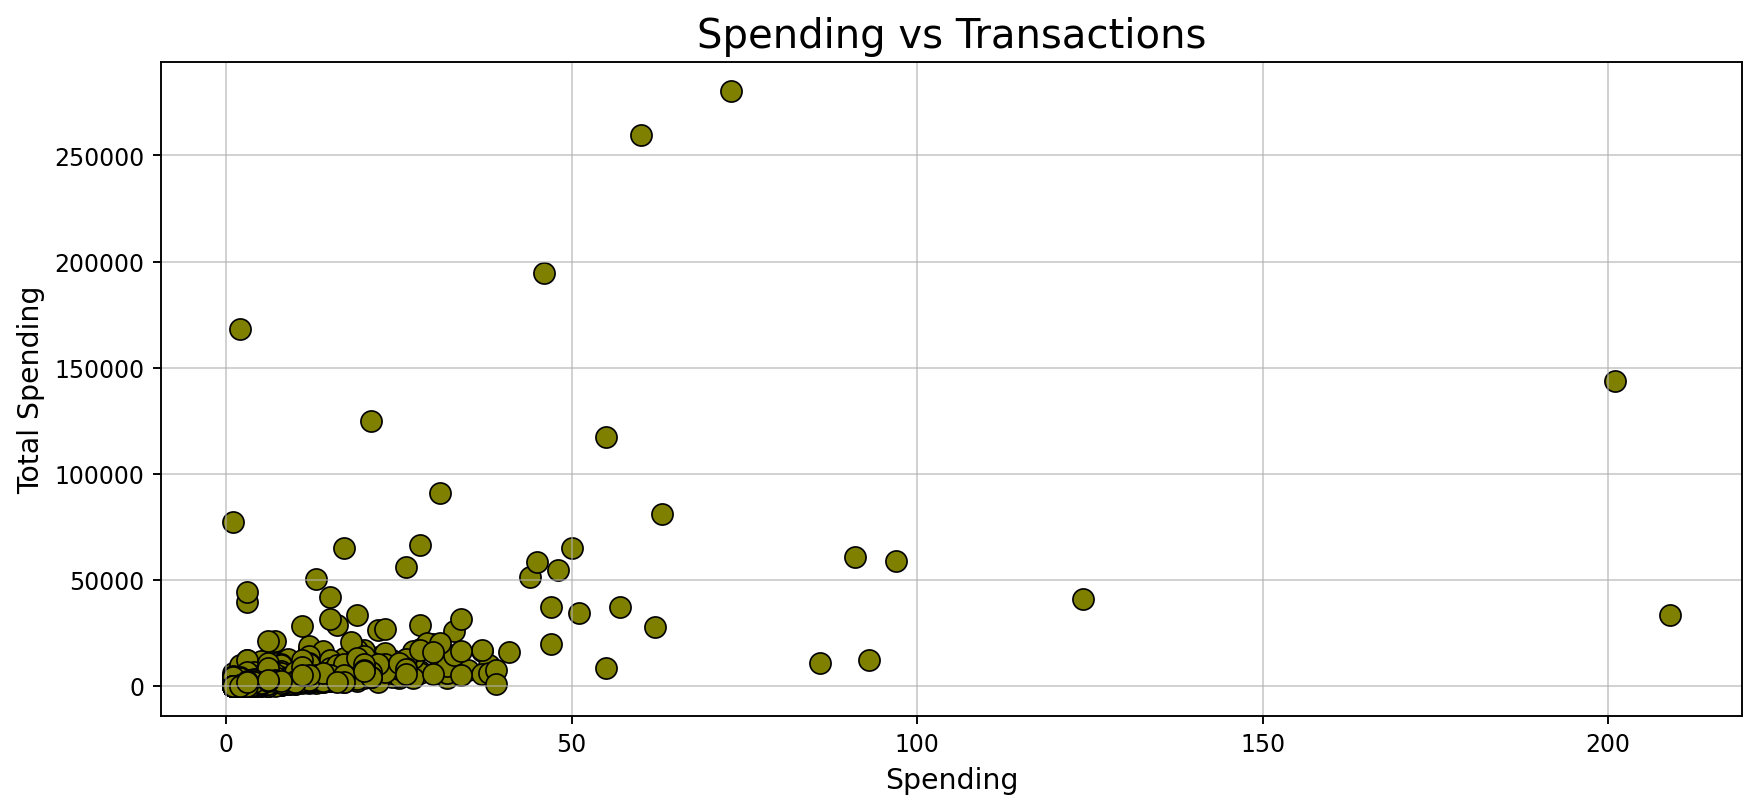

In [33]:
plt.figure(figsize=(12,5), dpi=170)
sns.scatterplot(x='TotalTransactions', y='TotalSpending', data=customer_df, color='olive', ec='k', s=80)
plt.title("Spending vs Transactions", fontsize=17)
plt.xlabel("Spending", fontsize=12)
plt.ylabel("Total Spending", fontsize=12)
plt.grid(alpha=0.6)
plt.show()

This relationship helps identify high-value frequent customers versus low-value occasional customers.

# Average Order Value vs Purchase Frequency

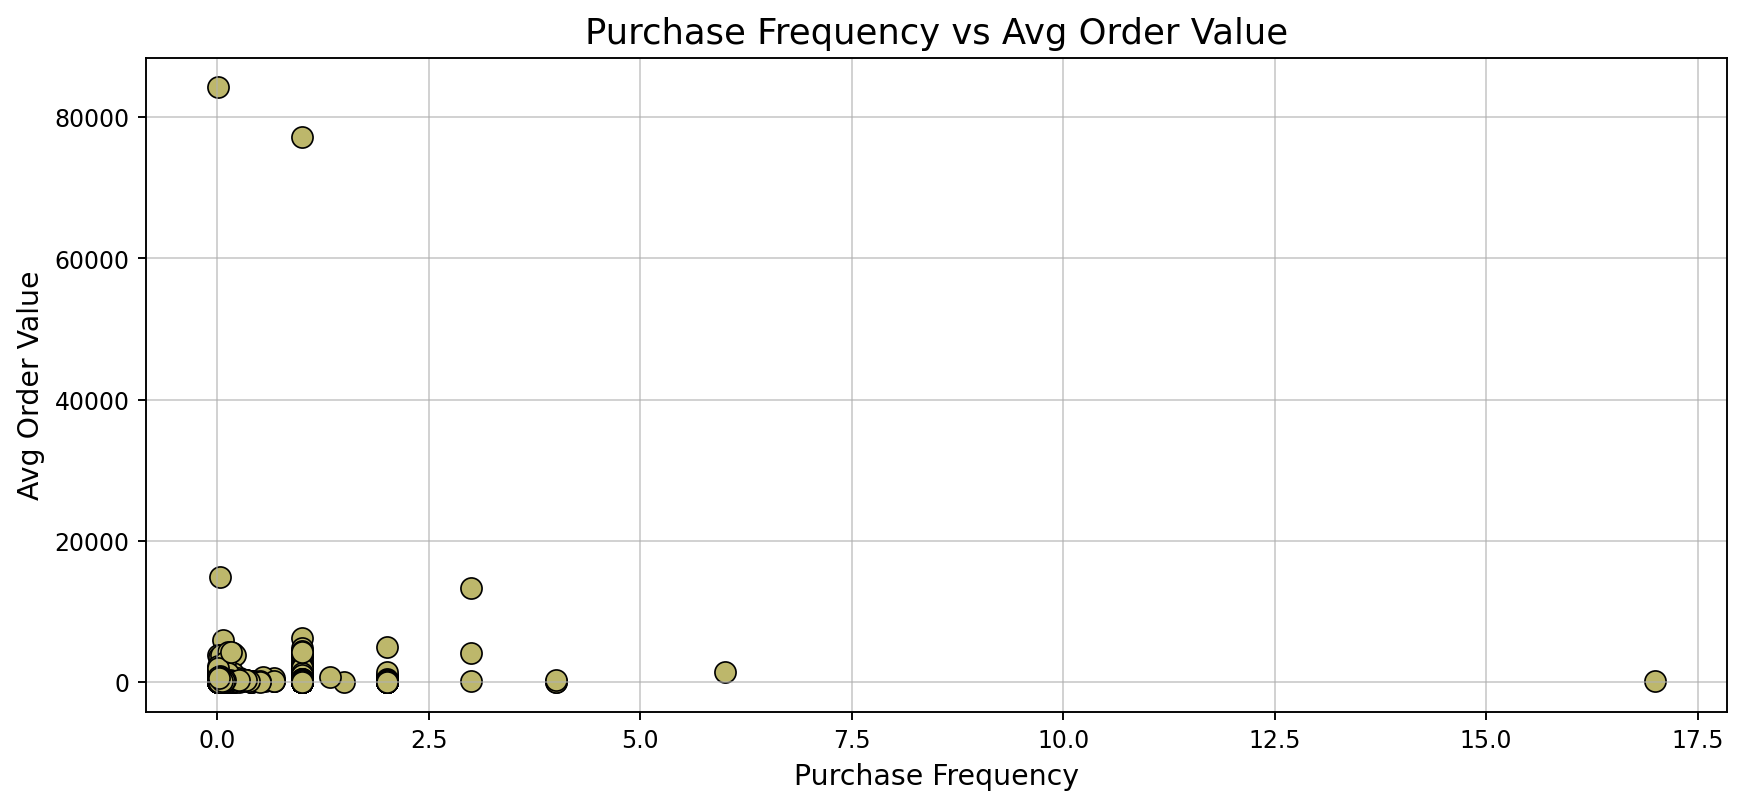

In [34]:
plt.figure(figsize=(12,5), dpi=170)
sns.scatterplot(x='PurchaseFrequency', y='AvgOrderValue', data=customer_df, color='darkkhaki', ec='k', s=80)
plt.title("Purchase Frequency vs Avg Order Value", fontsize=15)
plt.xlabel("Purchase Frequency", fontsize=12)
plt.ylabel("Avg Order Value", fontsize=12)
plt.grid(alpha=0.6)
plt.show()

Customers who purchase frequently and have high order values are likely the most profitable customer segment.

# Total Spending vs Customer Lifetime

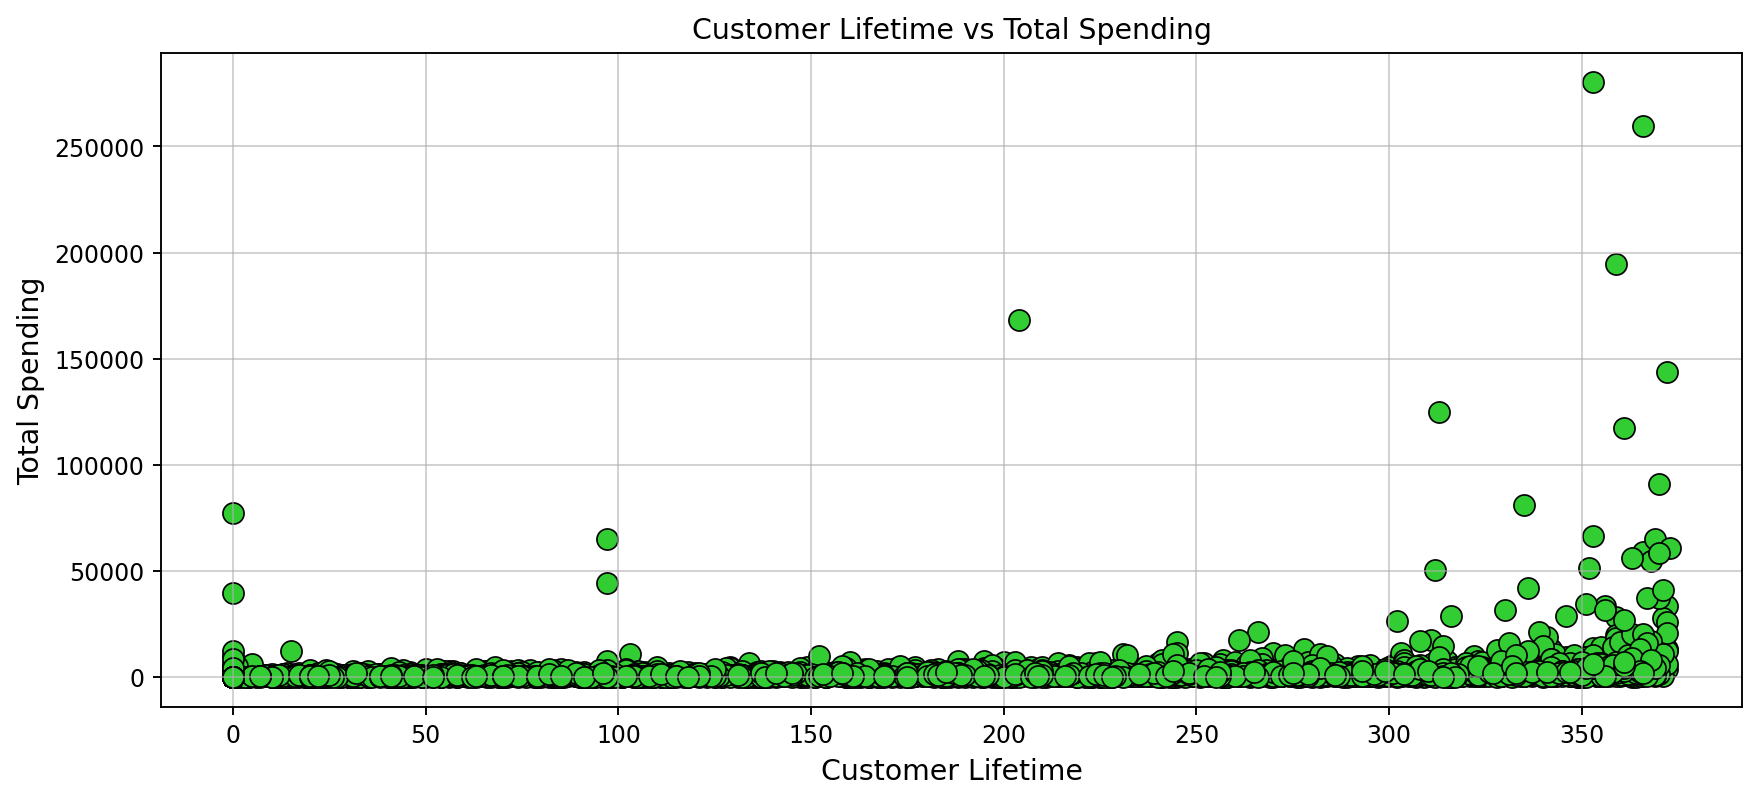

In [35]:
plt.figure(figsize=(12,5), dpi=170)
sns.scatterplot(x='CustomerLifetime', y='TotalSpending', data=customer_df, color='limegreen', ec='k', s=80)
plt.title("Customer Lifetime vs Total Spending")
plt.xlabel("Customer Lifetime", fontsize=12)
plt.ylabel("Total Spending", fontsize=12)
plt.grid(alpha=0.6)
plt.show()

Customers with longer lifetimes generally tend to spend more.

# Top Customers by Spending

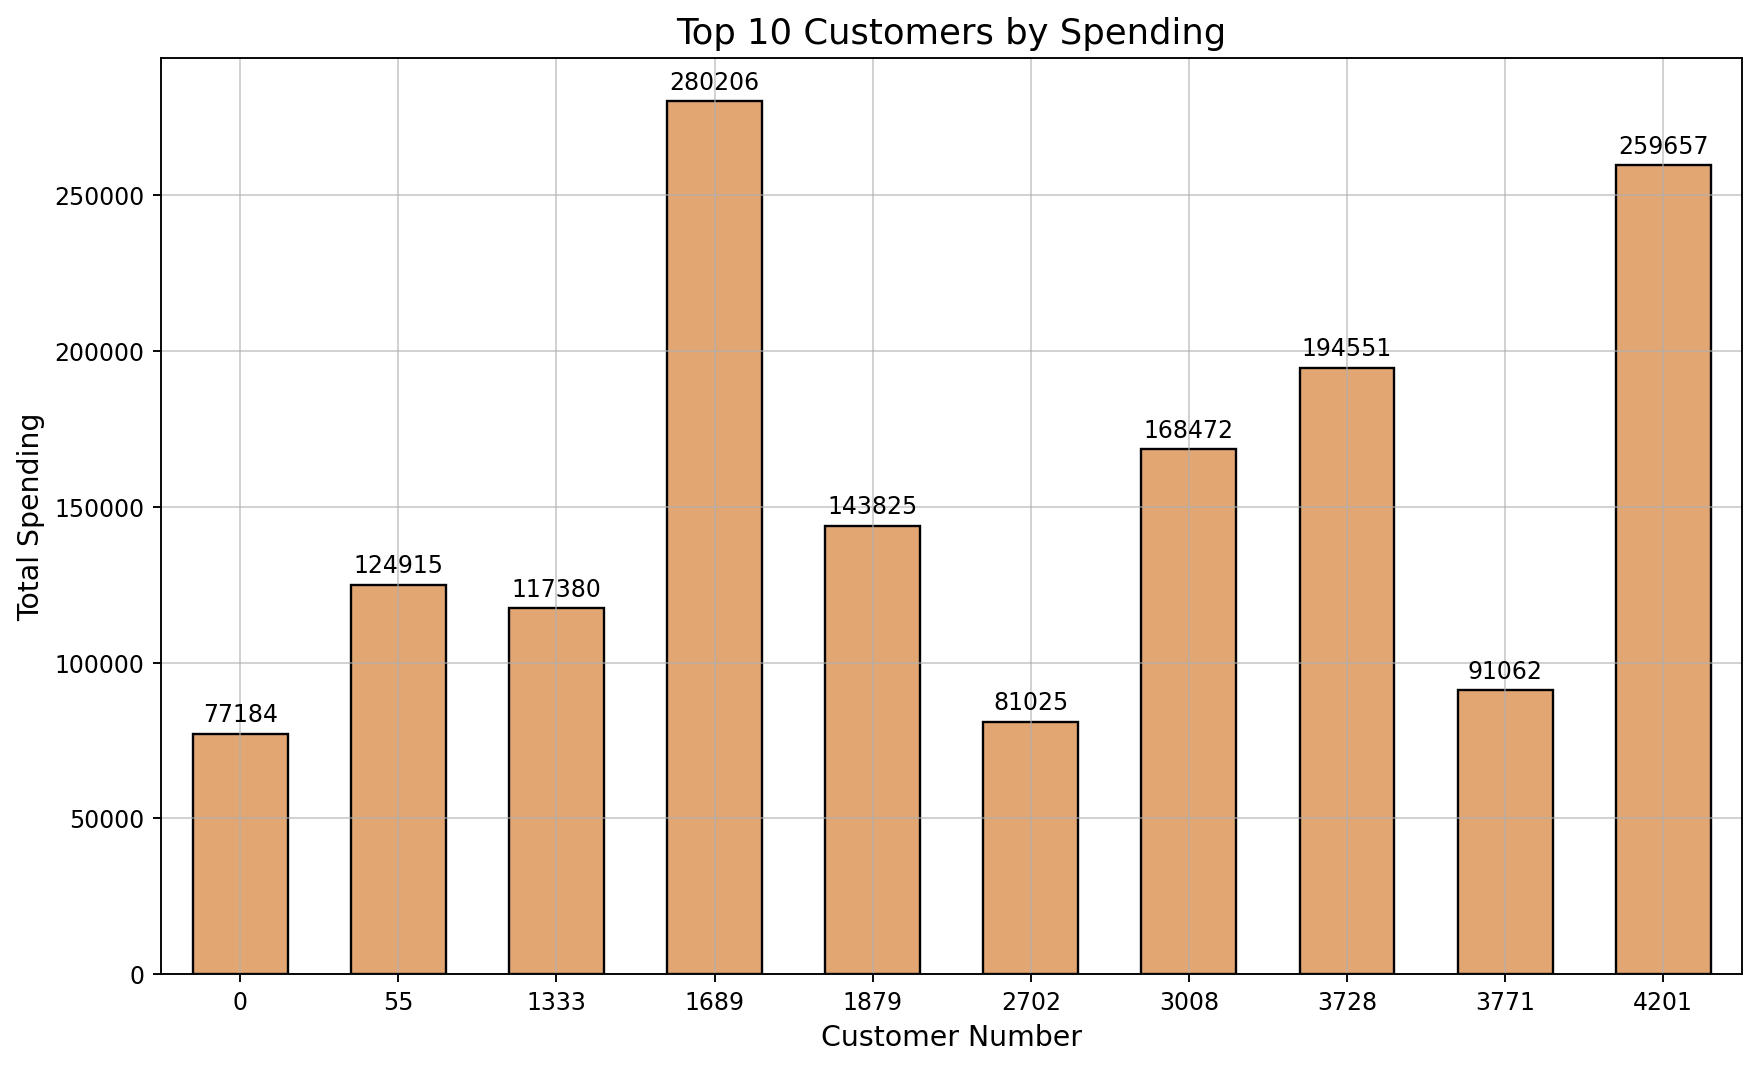

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

top_customers = customer_df.sort_values("TotalSpending", ascending=False).head(10)

plt.figure(figsize=(12,7), dpi=170)

ax = sns.barplot(
    x=top_customers.index,
    y=top_customers['TotalSpending'],
    ec='k',
    color='sandybrown',
    width=0.6
)

plt.title("Top 10 Customers by Spending", fontsize=15)
plt.xlabel("Customer Number", fontsize=12)
plt.ylabel("Total Spending", fontsize=12)
plt.grid(alpha=0.6)

# add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.show()

A small number of customers contribute disproportionately to revenue.

# Boxplot for Outlier Detection

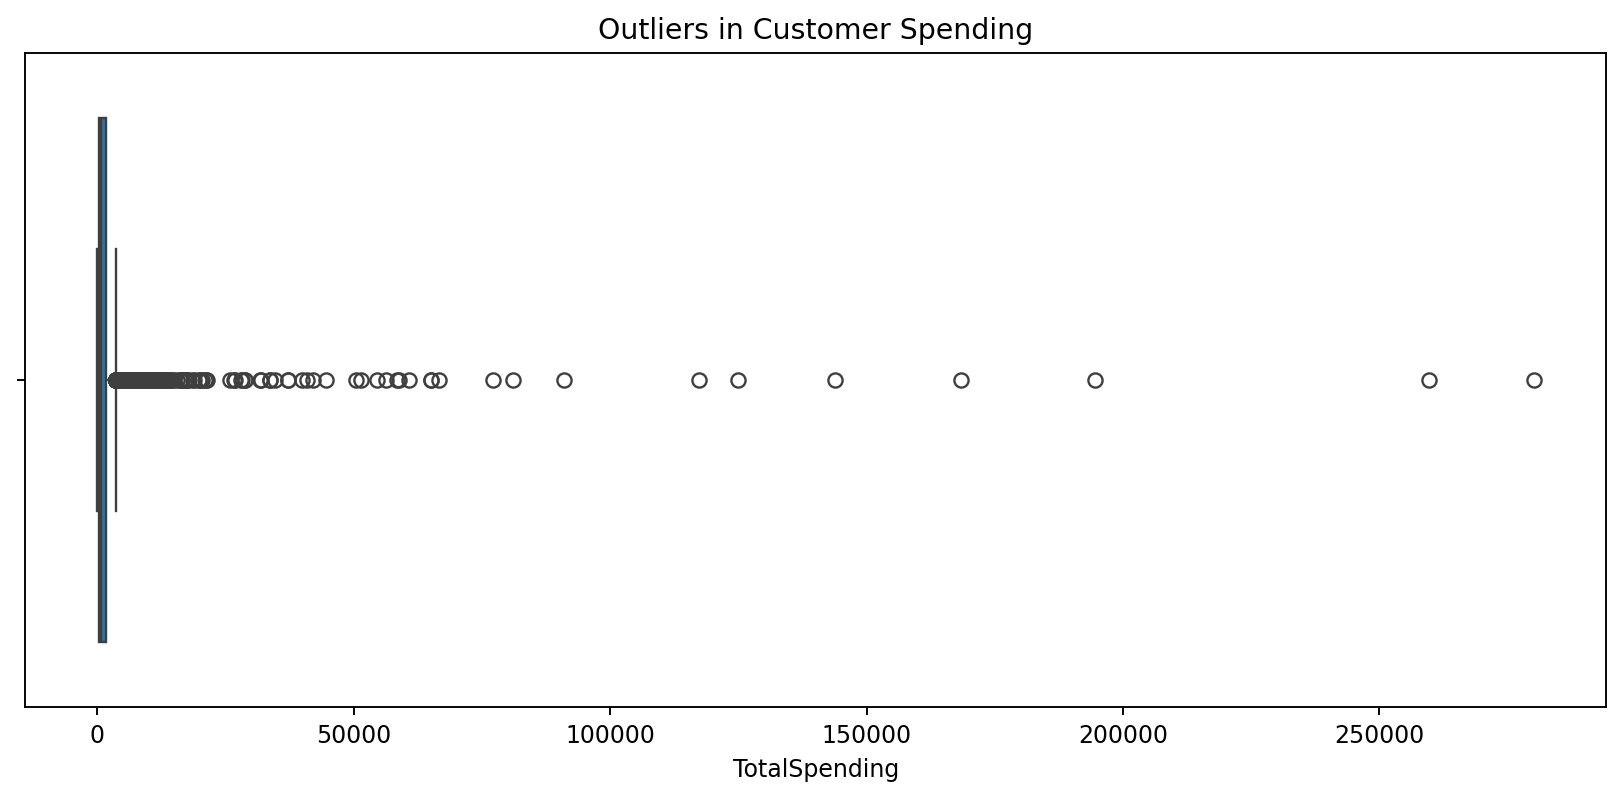

In [37]:
plt.figure(figsize=(12,5), dpi=170)
sns.boxplot(x=customer_df['TotalSpending'])
plt.title("Outliers in Customer Spending")
plt.show()

Boxplots reveal extreme spending values which may represent VIP customers or bulk buyers.

# Monthly Sales Trend

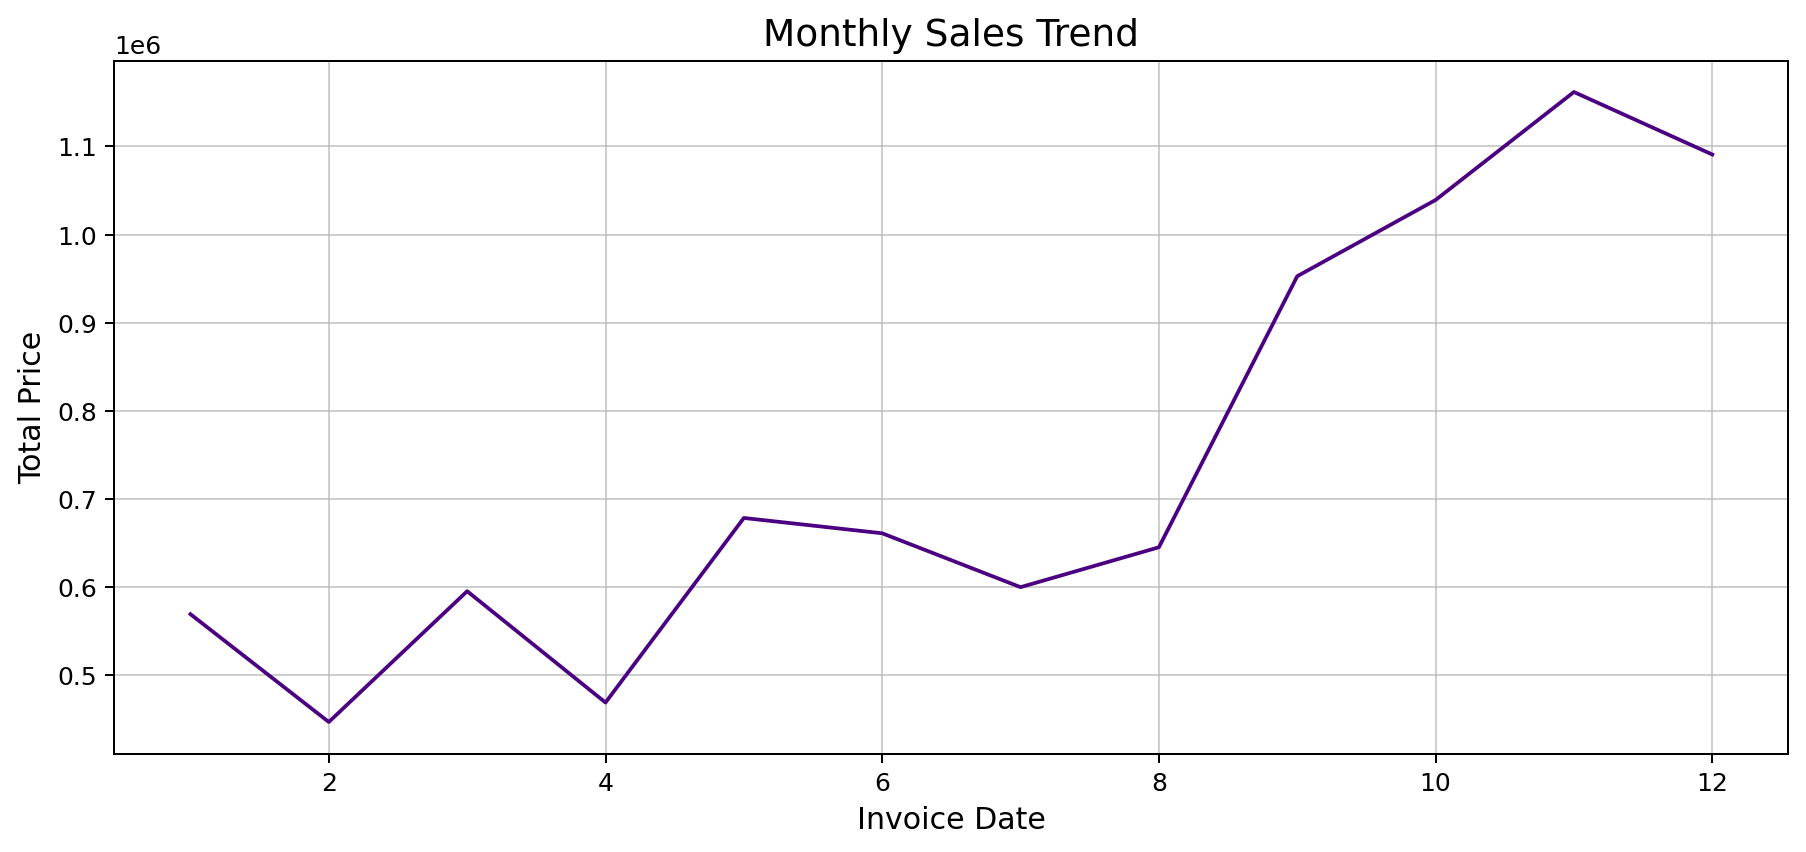

In [38]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.month)["TotalPrice"].sum()

plt.figure(figsize=(12,5), dpi=180)
monthly_sales.plot(kind='line', color='indigo')
plt.title("Monthly Sales Trend", fontsize=15)
plt.xlabel("Invoice Date", fontsize=12)
plt.ylabel("Total Price", fontsize=12)
plt.grid(alpha=0.6)
plt.show()

Seasonal patterns may appear, often showing peaks during holiday months.

# Purchase Time Analysis

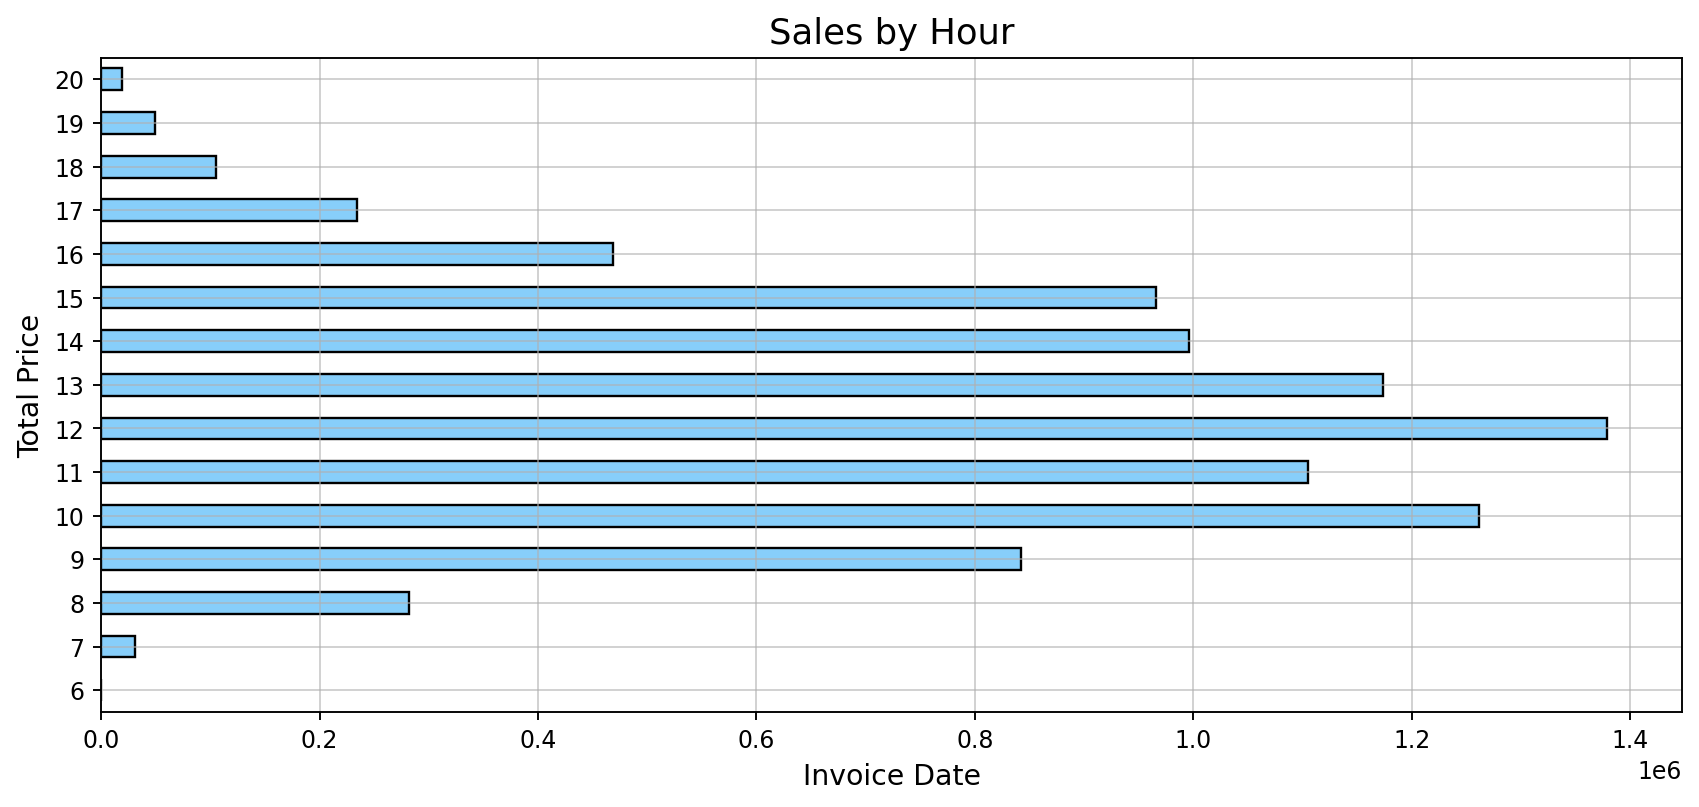

In [39]:
hourly_sales = df.groupby(df['InvoiceDate'].dt.hour)["TotalPrice"].sum()

plt.figure(figsize=(12,5), dpi=170)
hourly_sales.plot(kind='barh', color='lightskyblue', ec='k')
plt.title("Sales by Hour", fontsize=15)
plt.xlabel("Invoice Date", fontsize=12)
plt.ylabel("Total Price", fontsize=12)
plt.grid(alpha=0.6)
plt.show()

This reveals the time of day when customers are most active.

# Spending vs Quantity

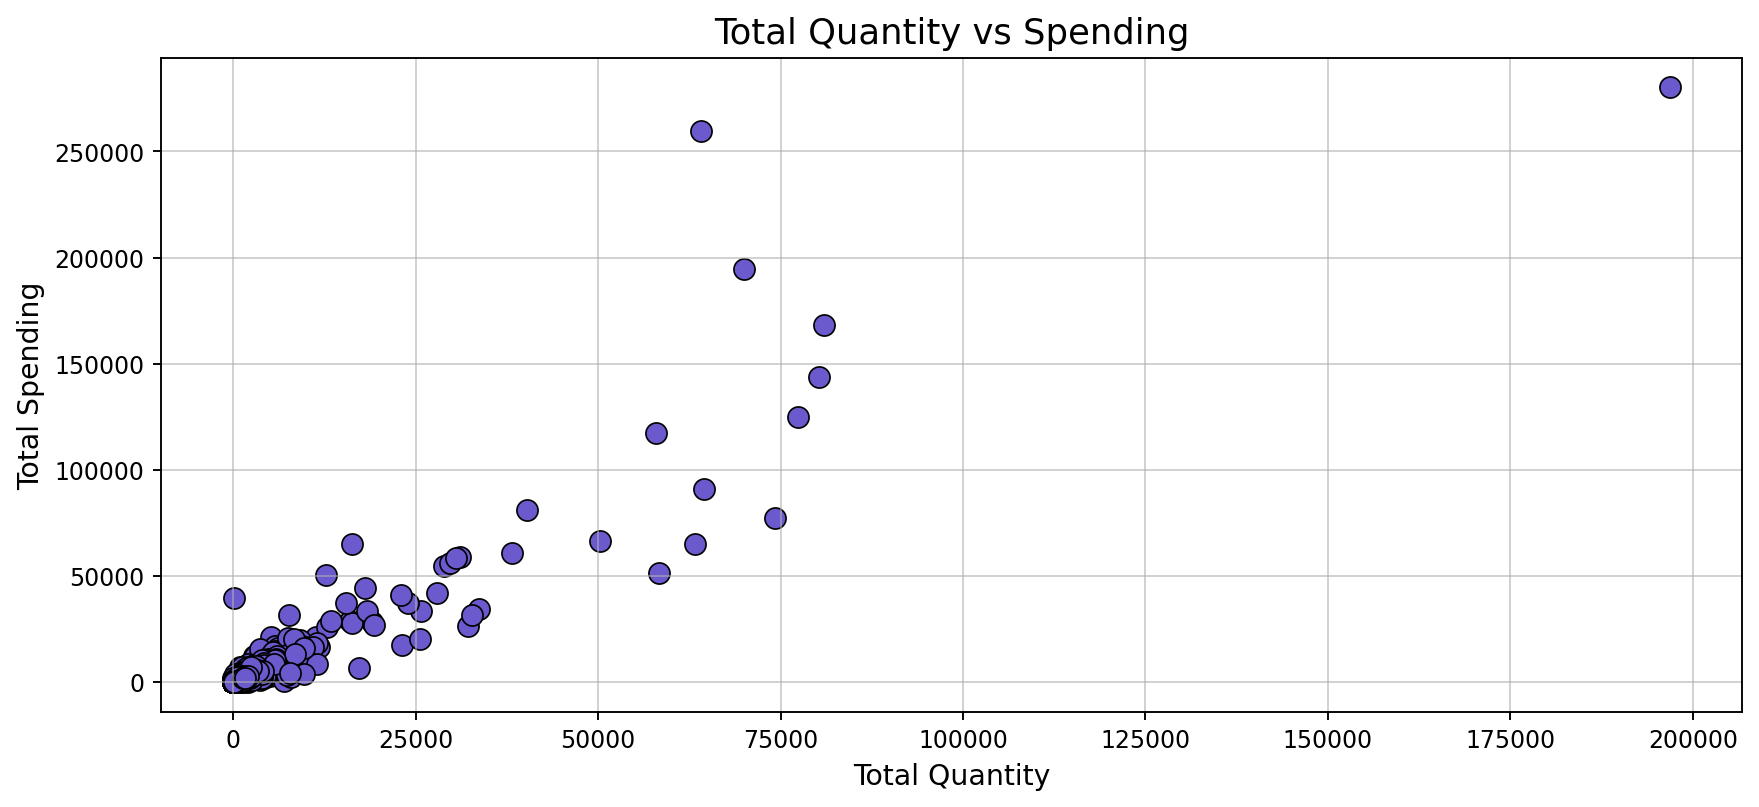

In [40]:
plt.figure(figsize=(12,5), dpi=170)
sns.scatterplot(x='TotalQuantity', y='TotalSpending', data=customer_df, ec='k', color='slateblue', s=80)
plt.title("Total Quantity vs Spending", fontsize=15)
plt.xlabel("Total Quantity", fontsize=12)
plt.ylabel("Total Spending", fontsize=12)
plt.grid(alpha=0.6)
plt.show()

Customers purchasing large quantities tend to generate higher revenue.

# Monthly Sales by Country

In [41]:
monthly_country = df.groupby(
    [df['InvoiceDate'].dt.month, "Country"]
)["TotalPrice"].sum().reset_index()

monthly_country.columns = ["Month","Country","Sales"]

In [42]:
fig = px.bar(
    monthly_country.head(100),
    x="Month",
    y="Sales",
    color="Country",
    barmode="group",
    title="Monthly Sales by Country",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(
    marker_line_width=1,
    marker_line_color="black"
)

fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Sales Revenue",
    height=900,
    width=1100
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

# Quantity Sold by Country

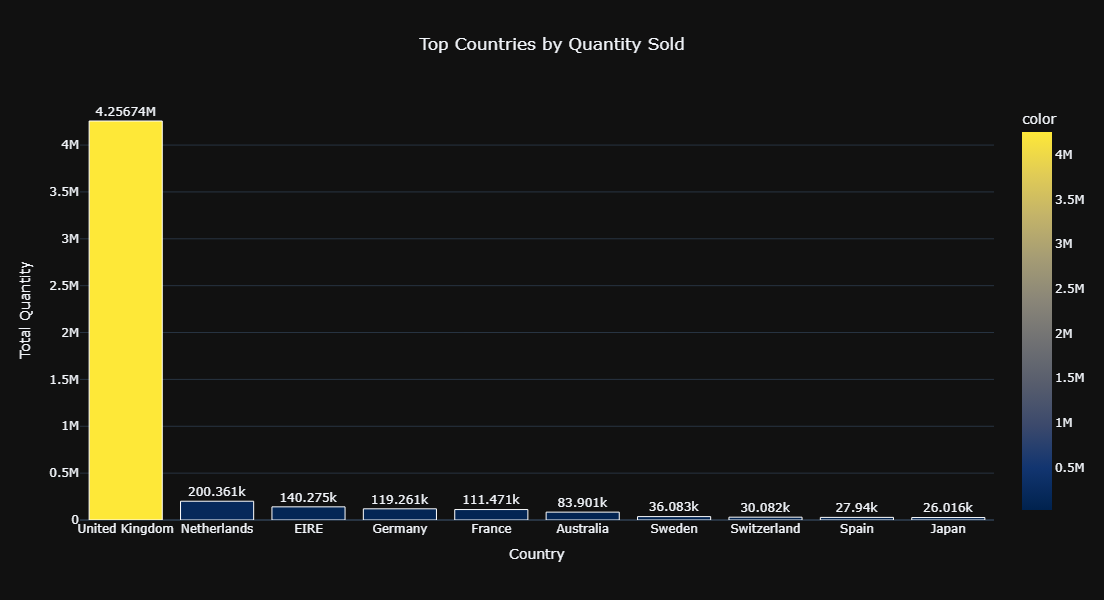

In [ ]:
country_quantity = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10)

fig = px.bar(
    x=country_quantity.index,
    y=country_quantity.values,
    color=country_quantity.values,
    title="Top Countries by Quantity Sold",
    color_continuous_scale="Cividis"
)

fig.update_traces(
    texttemplate='%{y}',
    textposition="outside",
    marker_line_width=1, marker_line_color='white'
)

fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    xaxis_title="Country",
    yaxis_title="Total Quantity",
    height=600,
    width=1110
)

fig.show()

# Sales Distribution by Country

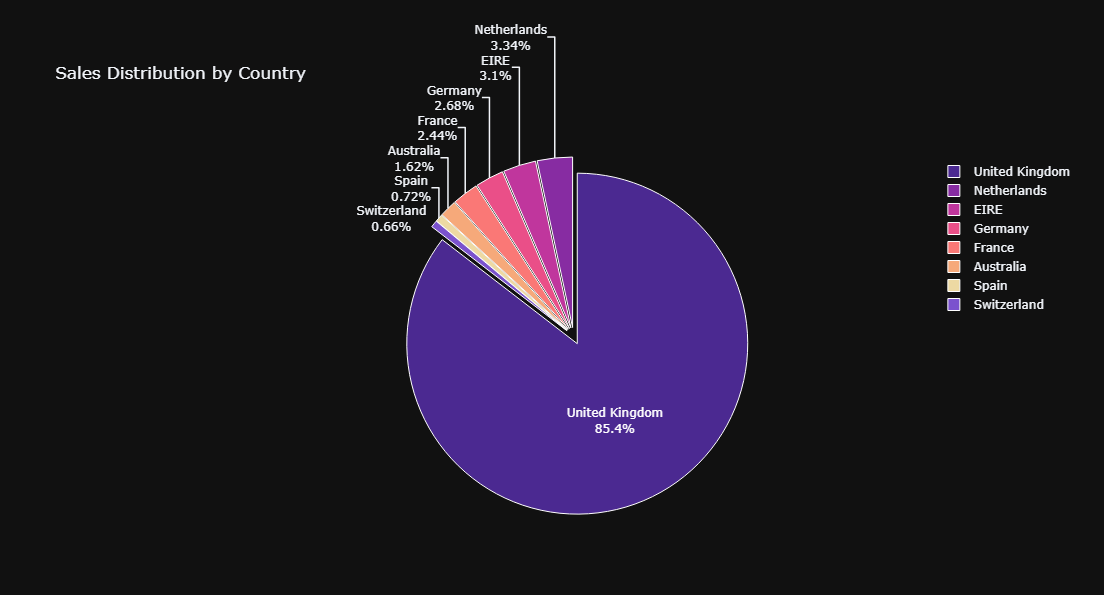

In [ ]:
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(8)

fig = px.pie(
    values=country_sales.values,
    names=country_sales.index,
    title="Sales Distribution by Country",
    color_discrete_sequence=px.colors.sequential.Agsunset
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05]*len(country_sales),
    marker_line_width=1, marker_line_color='white'
)

fig.update_layout(
    template="plotly_dark",
    height=595,
    width=1100
)

fig.show()

The pie chart clearly shows that a large percentage of revenue comes from a small number of countries.

# Monthly Revenue Trend

In [ ]:
monthly_sales = df.groupby(
    df['InvoiceDate'].dt.to_period("M")
)["TotalPrice"].sum().reset_index()

monthly_sales['InvoiceDate'] = monthly_sales['InvoiceDate'].astype(str)

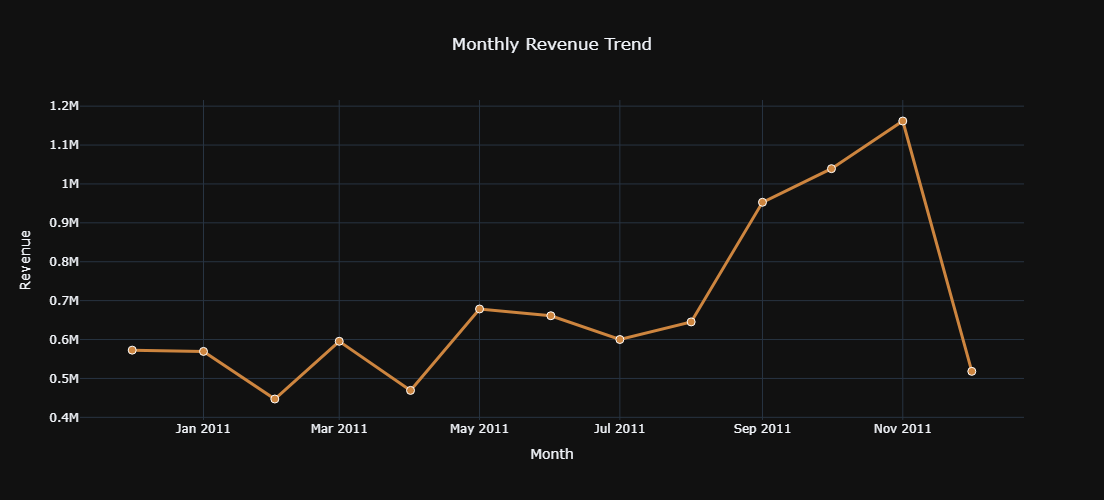

In [ ]:
fig = px.line(
    monthly_sales,
    x="InvoiceDate",
    y="TotalPrice",
    markers=True,
    title="Monthly Revenue Trend",
    color_discrete_sequence=["peru"]
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=8),
    marker_line_width=1, marker_line_color='white'
)

fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Revenue",
    height=500,
    width=1100
)

fig.show()

# Hourly Sales Pattern

In [43]:
hourly_sales = df.groupby(df['InvoiceDate'].dt.hour)["TotalPrice"].sum().reset_index()

fig = px.line(
    hourly_sales,
    x="InvoiceDate",
    y="TotalPrice",
    markers=True,
    title="Sales by Hour of Day",
    color_discrete_sequence=["lavender"]
)

fig.update_traces(
    line=dict(shape="spline", width=3),
    marker=dict(size=7),
    marker_line_width=1, marker_line_color='darkred'
)

fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    xaxis_title="Hour",
    yaxis_title="Sales",
    height=500,
    width=1100
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

# Scatter Matrix

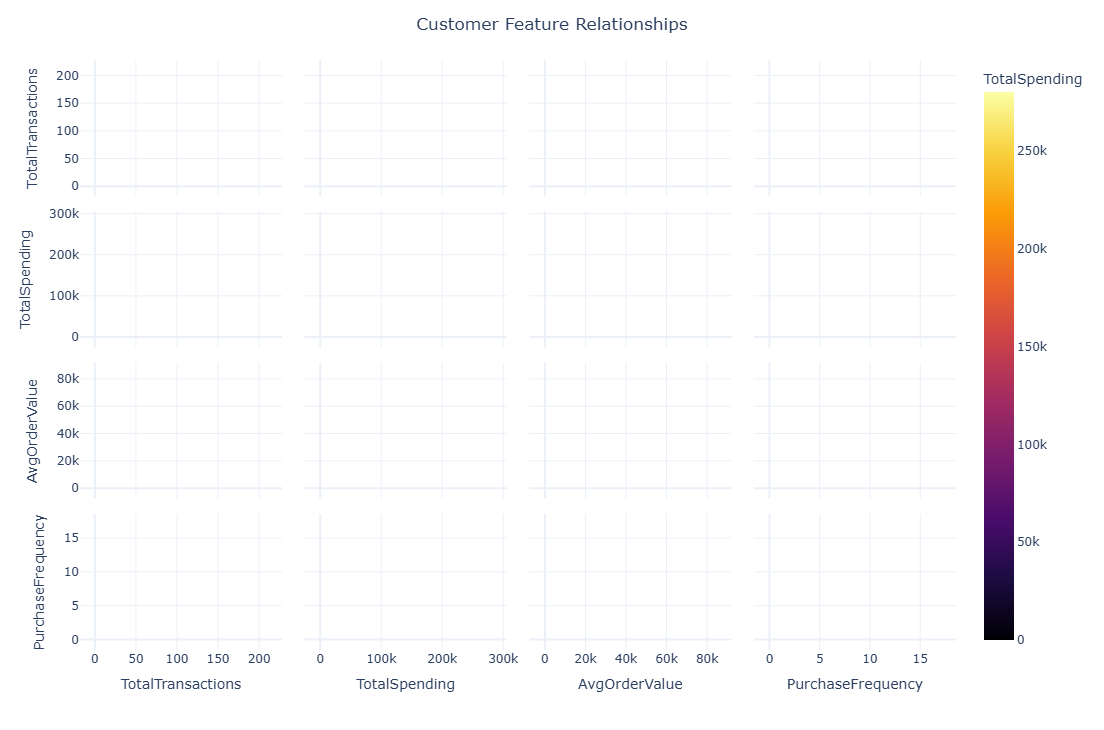

In [ ]:
fig = px.scatter_matrix(
    customer_df,
    dimensions=[
        "TotalTransactions",
        "TotalSpending",
        "AvgOrderValue",
        "PurchaseFrequency"
    ],
    color="TotalSpending",
    color_continuous_scale="Inferno"
)

fig.update_layout(
    title="Customer Feature Relationships",
    template="plotly_white",
    title_x=0.5,
    height=730,
    width=1100
)

fig.show()

# Data analytics 

## Top 10 Revenue Generating Products

In [44]:
top_products = (
    df.groupby("Description")[["TotalPrice","Quantity","UnitPrice"]]
    .sum()
    .sort_values(ascending=False, by=['Quantity','UnitPrice'])
    .head(10)
)

tp = pd.DataFrame(top_products)
tp

,TotalPrice,Quantity,UnitPrice
Description,,,
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,2.08
MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,241.62
WORLD WAR 2 GLIDERS ASSTD DESIGNS,13586.25,54415,138.40
JUMBO BAG RED RETROSPOT,85220.78,46181,3261.69
WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725,5867.22
ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362,2366.56
PACK OF 72 RETROSPOT CAKE CASES,16394.53,33693,585.49
POPCORN HOLDER,23427.71,30931,554.03
RABBIT NIGHT LIGHT,51346.20,27202,1695.74


This analysis identifies the products that generate the highest revenue. It helps businesses understand which products contribute most to overall sales and can guide inventory and marketing strategies.

In [45]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Month',
       'DayOfWeek', 'Hour'],
      dtype='str')

## Top 10 Customers by Total Spending

In [46]:
top_customers = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

tc = pd.DataFrame(top_customers)
tc

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


This query identifies the customers who contribute the most revenue. These high-value customers are important targets for loyalty programs and personalized marketing campaigns.

## Number of Unique Products Sold

In [47]:
unique_products = df["Description"].nunique()
unique_products

3877

This metric shows the total number of unique products available in the dataset, helping understand the diversity of the product catalog.

## Total Revenue by Country

In [48]:
country_sales = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

country_sales

cs = pd.DataFrame(country_sales)
cs.head(10)

,TotalPrice
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


This analysis reveals which countries generate the highest revenue. It helps businesses identify key geographical markets and plan regional expansion strategies.

## Total Quantity Sold by Product

In [49]:
top_quantity_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity_products

tqp = pd.DataFrame(top_quantity_products)
tqp

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


This query identifies the products sold in the highest quantities. It helps determine which items are most popular among customers.

## Average Order Value per Customer

In [50]:
avg_order_value = (
    df.groupby("CustomerID")["TotalPrice"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

aov = pd.DataFrame(avg_order_value)
aov

,TotalPrice
CustomerID,
12346.0,77183.600000
16446.0,56157.500000
15098.0,13305.500000
15749.0,4453.430000
15195.0,3861.000000
13135.0,3096.000000
17846.0,2033.100000
18087.0,2027.860000
16532.0,1687.200000


Average order value indicates how much a customer spends per transaction. Customers with high average order values are often premium buyers.

## Total Number of Transactions by Customer

In [51]:
customer_transactions = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

customer_transactions

ct = pd.DataFrame(customer_transactions)
ct.head(10)

,InvoiceNo
CustomerID,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


This query calculates the number of unique transactions made by each customer, helping identify loyal or frequent buyers.

## Monthly Sales Revenue

In [52]:
monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalPrice"]
    .sum()
)

ms = pd.DataFrame(monthly_sales)
ms

,TotalPrice
InvoiceDate,
2010-12,572713.890
2011-01,569445.040
2011-02,447137.350
2011-03,595500.760
2011-04,469200.361
2011-05,678594.560
2011-06,661213.690
2011-07,600091.011
2011-08,645343.900


Monthly sales analysis helps identify seasonal trends and periods of high or low sales activity.

## Top Countries by Number of Orders

In [53]:
country_orders = (
    df.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

co = pd.DataFrame(country_orders)
co.head(10)

,InvoiceNo
Country,
United Kingdom,16646
Germany,457
France,389
EIRE,260
Belgium,98
Netherlands,94
Spain,90
Portugal,57
Australia,57


This analysis identifies the countries with the highest number of transactions, highlighting regions with strong customer engagement.

## Customers Purchasing the Highest Quantity

In [54]:
high_quantity_customers = (
    df.groupby("CustomerID")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

hqc = pd.DataFrame(high_quantity_customers)
hqc

,Quantity
CustomerID,
14646.0,196915
16446.0,80997
14911.0,80265
12415.0,77374
12346.0,74215
17450.0,69993
17511.0,64549
18102.0,64124
13694.0,63312


Customers who purchase large quantities may represent wholesale buyers or bulk purchasers.

## Most Expensive Products

In [55]:
expensive_products = (
    df.groupby("Description")["UnitPrice"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

ep = pd.DataFrame(expensive_products)
ep

,UnitPrice
Description,
POSTAGE,8142.75
Manual,4161.06
DOTCOM POSTAGE,1599.26
PICNIC BASKET WICKER 60 PIECES,649.50
VINTAGE RED KITCHEN CABINET,295.00
VINTAGE BLUE KITCHEN CABINET,295.00
LOVE SEAT ANTIQUE WHITE METAL,195.00
RUSTIC SEVENTEEN DRAWER SIDEBOARD,165.00
REGENCY MIRROR WITH SHUTTERS,165.00


This query identifies the most expensive products in the dataset, which may represent premium items.

## Revenue Contribution by Top 5 Countries

In [56]:
top_countries = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .nlargest(5)
)

tc = pd.DataFrame(top_countries)
tc

,TotalPrice
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050


This insight highlights the countries that contribute the largest share of total revenue.

## Average Spending by Country

In [57]:
avg_country_spending = (
    df.groupby("Country")["TotalPrice"]
    .mean()
    .sort_values(ascending=False)
)

acs = pd.DataFrame(avg_country_spending)
acs.head(10)

,TotalPrice
Country,
Netherlands,121.003111
Australia,117.192310
Japan,116.561900
Singapore,95.852658
Sweden,85.096075
Denmark,49.882474
Lithuania,47.458857
Lebanon,37.641778
EIRE,36.697886


This analysis shows which countries have the highest average transaction value, indicating stronger purchasing power.

## Total Sales per Invoice

In [58]:
invoice_sales = (
    df.groupby("InvoiceNo")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

ps = pd.DataFrame(invoice_sales)
ps

,TotalPrice
InvoiceNo,
581483,168469.60
541431,77183.60
556444,38970.00
567423,31698.16
556917,22775.93
572209,22206.00
567381,22104.80
563614,21880.44
550461,21535.90


This query identifies the invoices with the highest total value, which may represent bulk purchases.

## Daily Sales Trend

In [59]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"]
    .sum()
)

ds = pd.DataFrame(daily_sales)
ds.head(10)

,TotalPrice
InvoiceDate,
2010-12-01,46376.49
2010-12-02,47316.53
2010-12-03,23921.71
2010-12-05,31771.60
2010-12-06,31215.64
2010-12-07,53795.31
2010-12-08,39248.82
2010-12-09,38231.90
2010-12-10,33650.28


Daily sales trends help monitor fluctuations in revenue and detect peak sales periods.

In [60]:
customer_revenue = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)

top_20_percent = int(len(customer_revenue) * 0.2)

customer_revenue.head(top_20_percent).sum() / customer_revenue.sum()

np.float64(0.7459402692156241)

## Top Customers by Recency

In [61]:
latest_date = df["InvoiceDate"].max()

recency = (
    df.groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
)

recency["RecencyDays"] = (latest_date - recency["InvoiceDate"]).dt.days

recency.sort_values("RecencyDays").head(10)

,CustomerID,InvoiceDate,RecencyDays
3662,17364.0,2011-12-09 09:00:00,0
71,12433.0,2011-12-09 10:02:00,0
934,13599.0,2011-12-08 16:10:00,0
892,13536.0,2011-12-08 16:38:00,0
3366,16933.0,2011-12-08 12:54:00,0
3823,17581.0,2011-12-09 12:21:00,0
2611,15898.0,2011-12-08 15:23:00,0
3333,16892.0,2011-12-08 13:18:00,0
3868,17644.0,2011-12-08 13:43:00,0
2620,15910.0,2011-12-09 10:51:00,0


Recency measures the number of days since a customer’s last purchase. Customers with lower recency values are more recently active and may be easier to retain.

## Customers with Highest Purchase Frequency

In [62]:
frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

fr = pd.DataFrame(frequency)
fr.head(10)

,InvoiceNo
CustomerID,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


Frequency represents how often customers purchase from the store. Customers with higher purchase frequency indicate stronger loyalty and engagement.

## Customers with Highest Monetary Value

In [63]:
monetary = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

mt = pd.DataFrame(monetary)
mt.head(10)

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


Monetary value represents the total amount spent by each customer. High monetary customers contribute the most revenue and are considered high-value customers.

## Customers with Highest Average Order Value

In [64]:
avg_order_value = (
    df.groupby("CustomerID")["TotalPrice"]
    .mean()
    .sort_values(ascending=False)
)

aov = pd.DataFrame(avg_order_value)
aov.head(10)

,TotalPrice
CustomerID,
12346.0,77183.600000
16446.0,56157.500000
15098.0,13305.500000
15749.0,4453.430000
15195.0,3861.000000
13135.0,3096.000000
17846.0,2033.100000
18087.0,2027.860000
16532.0,1687.200000


Average order value shows how much a customer typically spends per transaction. High values indicate premium buyers.

## Customers Buying the Most Products

In [65]:
top_quantity_customers = (
    df.groupby("CustomerID")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

tqc = pd.DataFrame(top_quantity_customers)
tqc.head(10)

,Quantity
CustomerID,
14646.0,196915
16446.0,80997
14911.0,80265
12415.0,77374
12346.0,74215
17450.0,69993
17511.0,64549
18102.0,64124
13694.0,63312


This identifies customers purchasing the largest number of items, which may represent bulk buyers or wholesalers.

## Customers with Longest Relationship

In [66]:
customer_lifetime = (
    df.groupby("CustomerID")["InvoiceDate"]
    .agg(["min", "max"])
)

customer_lifetime["LifetimeDays"] = (
    customer_lifetime["max"] - customer_lifetime["min"]
).dt.days

customer_lifetime.sort_values("LifetimeDays", ascending=False).head(10)

,min,max,LifetimeDays
CustomerID,,,
15311.0,2010-12-01 09:41:00,2011-12-09 12:00:00,373
12433.0,2010-12-01 13:24:00,2011-12-09 10:02:00,372
16210.0,2010-12-01 12:27:00,2011-12-08 12:36:00,372
14606.0,2010-12-01 16:57:00,2011-12-08 19:28:00,372
12748.0,2010-12-01 12:48:00,2011-12-09 12:20:00,372
12662.0,2010-12-01 13:04:00,2011-12-09 11:59:00,372
13777.0,2010-12-01 16:01:00,2011-12-09 12:25:00,372
15694.0,2010-12-02 07:49:00,2011-12-09 09:44:00,372
14911.0,2010-12-01 14:05:00,2011-12-08 15:54:00,372


Customer lifetime represents the duration between the first and last purchase. Long lifetimes indicate loyal customers.

## Customers with Highest Purchase Frequency per Month

In [67]:
monthly_frequency = (
    df.groupby(["CustomerID", df["InvoiceDate"].dt.to_period("M")])["InvoiceNo"]
    .nunique()
)

mf = monthly_frequency.sort_values(ascending=False).head(10)
mf1 = pd.DataFrame(mf)
mf1

InvoiceNo
CustomerID InvoiceDate           
12748.0    2011-11             45
           2010-12             35
14911.0    2011-11             34
17850.0    2010-12             34
14911.0    2011-09             28
12748.0    2011-05             24
14911.0    2011-10             24
           2011-06             17
           2011-07             16
17841.0    2011-11             16

This identifies customers who make multiple purchases within the same month, indicating highly engaged customers.

In [68]:
customer_df.to_csv("../data/Processed/Cutomer_sales_cleaned.csv", index=False)